In [1]:
!nvidia-smi

Wed Apr  8 18:14:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.83                 Driver Version: 581.83         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2050      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   43C    P0              7W /   50W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

In [3]:
print(torch.cuda.is_available())

True


In [4]:
print("started")

started


# Create and run a Local RAG pipeline from scratch

## What is RAG?

RAG stands for Retrieval-Augmented-Generation.

The Goal of RAG is to take information and pass it to an LLM so it can generate outputs based on that information.

* Retrieval - Find relevant information given a query, e.g "What are the macronutrients and what do they do ?""  ---> retrieves passages of text related to the macronutrients from a nutrition textbook.
* Augemented - We want to take relevant information we got from retrieval and augment our input (prompt) to an LLM with that relevant information.
* Generation - Take the first two steps and pass them to an LLM for generative outputs

## Why RAG?

The main goal of RAG is to improve the generation outputs of LLMs.

1. Prevent Hullucinations - LLMs are incredibly good at generating good *looking* text, however, this text doesn't mean that it's factual.
2. Work with custom data - Many base LLMs  are trained with internet-scale data. This means They have a fairly good understanding of language in general.
However, it also does a lot of their responses can be generic in nature. RAG helps to create specific responses based on specific documents (e.g. your own campanies customer support documents).

## What can RAG be used for?

* Customer Support Q&A chat - Treat your existing customer support documents as a resource and when a customer asks a question, you could have a retrieval system, retrieve relevant documentation snippets and then have an LLM craft those snippets into an answer, Think of this as a "chatbot for your documentation".
* Email chain analysis - Let's say you're a large insurance company and you have chain of emails of customer claims. You could use pipeline to find relevant information from those emails and then use an LLM to process that information into structured data.
* Company internal documentation chat
* Textbook Q&A - Let's say you're a nutrition student and you've got a 1200 page textbook read, you could build a RAG pipeline to go throughthe textbook and find relevant passages to the questions you have

Common theme here:": Take your relevant documents to a query and process them with an LLM

from this angle, you can consider an LLM as a calculator for words.

## why Local?

Fun.
privacy, speed, cost.

* privacy - If you have private documentation, maybe you don't want to send that to an API. You want to setup an LLM and run it on your own hardware.
* speed - whenever you have sending context query or prompt it takes time
* Cost - If you own your hardware, the cost is paid, it may have have a large cost to begin with, but overtime, you don't have to keep paying API fees.
* No vendor lockin - If you run your own software/hardware. If OpenAI/another large internet company shut down tommorrow, you could still run your business.

 ## What we're going to build

We're going to build RAG pipeline which enables us to chat with a PDF document, specifically an open-source [nutrition textbook](https://pressbooks.oer.hawaii.edu/humannutrition2/), ~1200 pages long.

You could call our project NutriChat!

We'll write the code to:
1. Open a PDF document (you could use almost any PDF here).
2. Format the text of the PDF textbook ready for an embedding model (this process is known as text splitting/chunking).
3. Embed all of the chunks of text in the textbook and turn them into numerical representation which we can store for later.
4. Build a retrieval system that uses vector search to find relevant chunks of text based on a query.
5. Create a prompt that incorporates the retrieved pieces of text.
6. Generate an answer to a query based on passages from the textbook.

The above steps can broken down into two major sections:
1. Document preprocessing/embedding creation (steps 1-3).
2. Search and answer (steps 4-6).

And that's the structure we'll follow.

It's similar to the workflow outlined on the NVIDIA blog which [details a local RAG pipeline](https://developer.nvidia.com/blog/rag-101-demystifying-retrieval-augmented-generation-pipelines/).

<img src="https://github.com/mrdbourke/simple-local-rag/blob/main/images/simple-local-rag-workflow-flowchart.png?raw=true" alt="flowchart of a local RAG workflow" />

**1. Document/Text processing and embedding creation**


Welcome to cooking show:
- Incredients:
  * PDF document of choice(note: this could be any type of document, I've just chosen to focus on PDFs for now).
  * Embedding model of choice.

Steps:
1. Import PDF document.
2. Process text for embedding (e.g. split into chunks of sentences).
3. Embed text chunks with embedding model.
4. Save embeddings to file for later (embeddings will store on file for many years or until you lose your hard drive)

### Import PDF 

In [5]:
import os
import requests

# Get pdf Document path 
pdf_path = "human-nutrition-text.pdf"

# Download pdf
if not os.path.exists(pdf_path):
    print(f"[INFO] file doesn't exist, downloading....")

    # Enter the url of pdf
    url  = "https://pressbooks.oer.hawaii.edu/humannutrition2/open/download?type=pdf"

    # The Local filename to save the downloaded file
    filename=pdf_path

    # Send a GET request to the URL
    response = requests.get(url)

    # Check if request was successful
    if response.status_code == 200:
        # Open the file and save it 
        with open(filename, "wb") as file:
            file.write(response.content)
        print(f"[INFO] The file has been download and saved as {filename}")
    else:
        print(f"[INFO] Failed to download the file. Status code: {response.status_code}")
else:
    print(f"File {pdf_path} exists.")

File human-nutrition-text.pdf exists.


we've got the pdf, now open it

In [6]:
import fitz # requires: pip install PyMuPDF --> work with pdf
from tqdm.auto import tqdm # pip install tqdm --> loader visuals

def text_formatter(text: str) -> str:
    """Performs minor formatting on text."""
    cleaned_text = text.replace("\n"," ").strip()

    # Potentially more text formatting functions can go here
    return cleaned_text

def open_and_read_pdf(pdf_path: str) -> list[dict]:
    doc = fitz.open(pdf_path)
    pages_and_texts= []
    for page_number, page in tqdm(enumerate(doc)):
        text = page.get_text()
        text=text_formatter(text=text)
        pages_and_texts.append({"page_number":page_number-41,
                                "page_char_count": len(text),
                                "page_word_count" :len(text.split(" ")),
                                "page_sentence_count_raw":len(text.split(". ")),
                                "page_token_count": len(text) / 4, # 1 token = ~4 characters
                                "text":text})
    return pages_and_texts

pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:2]

0it [00:00, ?it/s]

[{'page_number': -41,
  'page_char_count': 29,
  'page_word_count': 4,
  'page_sentence_count_raw': 1,
  'page_token_count': 7.25,
  'text': 'Human Nutrition: 2020 Edition'},
 {'page_number': -40,
  'page_char_count': 0,
  'page_word_count': 1,
  'page_sentence_count_raw': 1,
  'page_token_count': 0.0,
  'text': ''}]

In [7]:
import random

random.sample(pages_and_texts, k=3)

[{'page_number': 821,
  'page_char_count': 2138,
  'page_word_count': 405,
  'page_sentence_count_raw': 21,
  'page_token_count': 534.5,
  'text': 'the nipple. Groups of alveoli connected by ducts are organized into  lobes, or sections, of the breast. The breast contains 15 to 25 lobes,  and each lobe contains 10 to 100 alveoli.  The areola is the darker skin around the nipple and is a visual  target that helps the baby find the breast. The bumps on the areola  are glands that provide lubrication and protection to the tissue.  These glands also produce a scent to help the baby find the nipple.  The nipple and areola contain erectile smooth muscles that contract  to make the nipple protrude more during breastfeeding. Nipples  come in many sizes and shapes and contain from 4 to 18 openings  for the milk to flow out. Mothers do not need to do anything to get  their nipples ready to breastfeed.  Breast size is mainly determined by the amount of fat in the  breast; the milk-making structure

In [8]:
import pandas as pd

df= pd.DataFrame(pages_and_texts)
df.tail()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,text
1203,1162,1676,268,18,419.00,39. Exercise 10.2 & 11.3 reused “Egg Oval Food...
1204,1163,1617,262,10,404.25,Images / Pixabay License; “Pumpkin Cartoon Ora...
1205,1164,1715,273,13,428.75,Flashcard Images Note: Most images in the fla...
1206,1165,1733,275,13,433.25,ShareAlike 11. Organs reused “Pancreas Organ ...
1207,1166,257,46,3,64.25,23. Vitamin D reused “The Functions of Vitamin...


In [9]:
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,199.50,10.52,287.00
std,348.86,560.38,95.83,6.55,140.10
min,-41.00,0.00,1.00,1.00,0.00
25%,260.75,762.00,134.00,5.00,190.50
50%,562.50,1231.50,216.00,10.00,307.88
75%,864.25,1603.50,272.00,15.00,400.88
max,1166.00,2308.00,430.00,39.00,577.00


Why would we care about token count?

Token count is important to think about because:
1. Embedding model's don't deal with infinite tokens.
2. LLMs don't deal with infinite tokens

For example an embedding model may have been trained to embed seequences of 384 tokens into numerical space.
see: https://sbert.net/docs/sentence_transformer/pretrained_models.html

As For LLMs, they can't accept infinite tokens in their context window

### Further text processing (splitting pages into sentences)

Two ways to do this:
1. We've done this by splitting on `". "`.
2. We can do this with a NLP library such as spaCy (https://spacy.io/) and nltk (https://www.nltk.org/).

In [10]:
from spacy.lang.en import English

nlp = English()

# Add a sentencizer pipeline, see: https://spacy.io/api/sentencizer#pipe
nlp.add_pipe("sentencizer")

# create document instance as an example
doc = nlp("This is a sentence. This another sentence. I like elephants.")
assert len(list(doc.sents)) == 3

#print out our sentences split
list(doc.sents)

[This is a sentence., This another sentence., I like elephants.]

In [11]:
pages_and_texts[53]

{'page_number': 12,
 'page_char_count': 1326,
 'page_word_count': 220,
 'page_sentence_count_raw': 11,
 'page_token_count': 331.5,
 'text': 'Protein  Necessary for tissue formation, cell reparation, and  hormone and enzyme production. It is essential for  building strong muscles and a healthy immune system.  Carbohydrates  Provide a ready source of energy for the body and  provide structural constituents for the formation of  cells.  Fat  Provides stored energy for the body, functions as  structural components of cells and also as signaling  molecules for proper cellular communication. It  provides insulation to vital organs and works to  maintain body temperature.  Vitamins  Regulate body processes and promote normal  body-system functions.  Minerals  Regulate body processes, are necessary for proper  cellular function, and comprise body tissue.  Water  Transports essential nutrients to all body parts,  transports waste products for disposal, and aids with  body temperature maintenanc

In [12]:
for item in tqdm(pages_and_texts):
    item["sentences"]=list(nlp(item["text"]).sents)

    # make sure all sentences are str (def spacy datadype)
    item["sentences"]=[str(sentence) for sentence in item["sentences"]]

    # Count the sentences
    item["page_sentence_count_spacy"] = len(item["sentences"])

  0%|          | 0/1208 [00:00<?, ?it/s]

In [13]:
random.sample(pages_and_texts,k=1)

[{'page_number': 1138,
  'page_char_count': 1416,
  'page_word_count': 224,
  'page_sentence_count_raw': 15,
  'page_token_count': 354.0,
  'text': 'programs and other forms of public assistance if their income is less  than a certain percentage of the federal poverty level, along with  other qualifications.  USDA Food Assistance Programs  Government food and nutrition assistance programs that are  organized and operated by the USDA work to increase food security.  They provide low-income households with access to food, the tools  for consuming a healthy diet, and education about nutrition. The  USDA monitors the extent and severity of food insecurity via an  annual survey. This contributes to the efficiency of food assistance  programs as well as the effectiveness of private charities and other  initiatives aimed at reducing food insecurity.10  The Supplemental Nutrition Assistance Program  Formerly known as the Food Stamp Program, the Supplemental  Nutrition Assistance Program (SNAP)

In [14]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,199.50,10.52,287.00,10.32
std,348.86,560.38,95.83,6.55,140.10,6.30
min,-41.00,0.00,1.00,1.00,0.00,0.00
25%,260.75,762.00,134.00,5.00,190.50,5.00
50%,562.50,1231.50,216.00,10.00,307.88,10.00
75%,864.25,1603.50,272.00,15.00,400.88,15.00
max,1166.00,2308.00,430.00,39.00,577.00,28.00


### Chunking our sentences together

The concept of splitting larger pieces of text into smaller once is often referred too as splitting or chunking.
There is no 100% correct way to do this .
we'll keep it simple and split into groups of 10 sentences (however, you could also try 5,7,8 whatever you like).
https://docs.langchain.com/oss/python/integrations/splitters

Why we do this:
1. So our texts are easier to filter (smaller groups of text can be easier to inspect that large passages of text.)
2. So our text chunks can fit into our embedding model context window (e.g 384 token as a limit)
3. so our context passed to an llm can be more specific and focused.

In [15]:
# Define split size to turn groups of sentences into chunks
num_sentence_chunk_size = 10

# Create a function to split lists of texts recursively into chunk size
# e.g [20] --> [10,10]
def split_list(input_list: list[str],
               slice_size: int) -> list[list[str]]:
    return [input_list[i:i+slice_size] for i in range(0, len(input_list),slice_size)]

test_list= list(range(25))
split_list(test_list,num_sentence_chunk_size)

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [20, 21, 22, 23, 24]]

In [16]:
# Loop through pages and texts and splt sentences into chunks
for item in tqdm(pages_and_texts):
    item["sentence_chunks"] = split_list(input_list=item["sentences"],
                                         slice_size=num_sentence_chunk_size)
    item["num_chunks"]=len(item["sentence_chunks"])

  0%|          | 0/1208 [00:00<?, ?it/s]

In [17]:
random.sample(pages_and_texts,k=3)

[{'page_number': 119,
  'page_char_count': 200,
  'page_word_count': 35,
  'page_sentence_count_raw': 2,
  'page_token_count': 50.0,
  'text': 'An interactive or media element has been  excluded from this version of the text. You can  view it online here:  http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=111    The Muscular System  |  119',
  'sentences': ['An interactive or media element has been  excluded from this version of the text.',
   'You can  view it online here:  http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=111    The Muscular System  |  119'],
  'page_sentence_count_spacy': 2,
  'sentence_chunks': [['An interactive or media element has been  excluded from this version of the text.',
    'You can  view it online here:  http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=111    The Muscular System  |  119']],
  'num_chunks': 1},
 {'page_number': 231,
  'page_char_count': 1425,
  'page_word_count': 245,
  'page_sentence_count_raw': 16,
  'page_token_count': 356.25

In [18]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,199.50,10.52,287.00,10.32,1.53
std,348.86,560.38,95.83,6.55,140.10,6.30,0.64
min,-41.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,260.75,762.00,134.00,5.00,190.50,5.00,1.00
50%,562.50,1231.50,216.00,10.00,307.88,10.00,1.00
75%,864.25,1603.50,272.00,15.00,400.88,15.00,2.00
max,1166.00,2308.00,430.00,39.00,577.00,28.00,3.00


### Splitting each chunk into its own item

We'd like to embed each chunk of sentences into its own numerical representation

That'll give us a good level of granularity.

meaning, we can dive specifically into the text sample that was used in our model.

In [19]:
import re

# Split each chunk into its own item
pages_and_chunks = []
for item in tqdm(pages_and_texts):
   for sentence_chunk in item["sentence_chunks"]:
       chunk_dict={}
       chunk_dict["page_number"]=item["page_number"]

       # Join the sentences together into a parapgrph-style
       joined_sentence_chunk ="".join(sentence_chunk).replace("  "," ").strip()
       joined_sentence_chunk = re.sub(r'\.([A-Z])',r'. \1', joined_sentence_chunk) # ".A" => ". A"(will work for any capital letter)

       chunk_dict["sentence_chunk"] = joined_sentence_chunk

       # Get some stats on our chunks
       chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
       chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
       chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4 #1 token = ~4 chars

       pages_and_chunks.append(chunk_dict)

len(pages_and_chunks)

  0%|          | 0/1208 [00:00<?, ?it/s]

1843

In [20]:
random.sample(pages_and_chunks, k=1)

[{'page_number': 863,
  'sentence_chunk': 'downloadable versions (EPUB, Digital PDF, Print_PDF, or Open Document). Learning activities may be used across various mobile devices, however, for the best user experience it is strongly recommended that users complete these activities using a desktop or laptop computer and in Google Chrome.  An interactive or media element has been excluded from this version of the text. You can view it online here: http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=458 An interactive or media element has been excluded from this version of the text. You can view it online here: http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=458 Toddler Years | 863',
  'chunk_char_count': 648,
  'chunk_word_count': 92,
  'chunk_token_count': 162.0}]

In [21]:
df = pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,1843.00,1843.00,1843.00,1843.00
mean,583.38,734.10,112.74,183.52
std,347.79,447.51,71.24,111.88
min,-41.00,12.00,3.00,3.00
25%,280.50,315.00,45.00,78.75
50%,586.00,745.00,115.00,186.25
75%,890.00,1118.00,173.00,279.50
max,1166.00,1830.00,297.00,457.50


In [22]:
df.sample(5)

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count
1058,682,Image by Chris55 / CC BY 4.0 A large goiter b...,224,41,56.0
1147,747,The recommended consumption amount for seafood...,1004,167,251.0
1511,969,"progresses, the amount of red blood cells will...",1096,167,274.0
1435,921,The decrease in physical activity that is typi...,564,87,141.0
1440,924,"For example, solid foods can be pureed, ground...",1266,201,316.5


### Filter chunks of text for short chunks

These chunks may not contaiin much useful information.

In [23]:
# Show random chunks with under 30 tokens in length
min_token_length=30
for row in df[df["chunk_token_count"] <=min_token_length].sample(5).iterrows():
    print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}')

Chunk token count: 25.5 | Text: http://www.ajcn.org/cgi/ pmidlookup?view=long&pmid=10197575. Accessed October 6, 2017. 640 | Magnesium
Chunk token count: 9.75 | Text: 1002 | The Causes of Food Contamination
Chunk token count: 5.25 | Text: 754 | MyPlate Planner
Chunk token count: 24.25 | Text: http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=225 330 | Digestion and Absorption of Lipids
Chunk token count: 17.75 | Text: Last updated February 16, 2011. The Benefits of Physical Activity | 945


In [24]:
# Filter our DataFrame for rows with under 30 tokens
pages_and_chunks_over_min_token_len = df[df["chunk_token_count"] > min_token_length].to_dict(orient="records")
pages_and_chunks_over_min_token_len[:2]

[{'page_number': -39,
  'sentence_chunk': 'Human Nutrition: 2020 Edition UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN NUTRITION PROGRAM ALAN TITCHENAL, SKYLAR HARA, NOEMI ARCEO CAACBAY, WILLIAM MEINKE-LAU, YA-YUN YANG, MARIE KAINOA FIALKOWSKI REVILLA, JENNIFER DRAPER, GEMADY LANGFELDER, CHERYL GIBBY, CHYNA NICOLE CHUN, AND ALLISON CALABRESE',
  'chunk_char_count': 308,
  'chunk_word_count': 42,
  'chunk_token_count': 77.0},
 {'page_number': -38,
  'sentence_chunk': 'Human Nutrition: 2020 Edition by University of Hawai‘i at Mānoa Food Science and Human Nutrition Program is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.',
  'chunk_char_count': 210,
  'chunk_word_count': 30,
  'chunk_token_count': 52.5}]

In [25]:
random.sample(pages_and_chunks_over_min_token_len,k=1)

[{'page_number': 255,
  'sentence_chunk': 'excess of fifty thousand single glucose units and is highly branched, allowing for the rapid dissemination of glucose when it is needed to make cellular energy. The amount of glycogen in the body at any one time is equivalent to about 4,000 kilocalories—3,000 in muscle tissue and 1,000 in the liver. Prolonged muscle use (such as exercise for longer than a few hours) can deplete the glycogen energy reserve. Remember that this is referred to as “hitting the wall” or “bonking” and is characterized by fatigue and a decrease in exercise performance. The weakening of muscles sets in because it takes longer to transform the chemical energy in fatty acids and proteins to usable energy than glucose. After prolonged exercise, glycogen is gone and muscles must rely more on lipids and proteins as an energy source. Athletes can increase their glycogen reserve modestly by reducing training intensity and increasing their carbohydrate intake to between 60 and

### Embedding our text chunks

Embeddings are a broad but powerful concept.

While humans understand text, machines understand numbers.

What we'd like to do:
 - Turn our text chunks into numbers, specifically embeddings.

A useful numerical representation.

The best part about embeddings is that are a `learned` representation.

```
{"the":0,
 "a":1,
 ```
for a great resource on learning embeddings, see here:https://vickiboykis.com/what_are_embeddings/

In [26]:
from sentence_transformers import SentenceTransformer
embedding_model= SentenceTransformer(model_name_or_path="all-mpnet-base-v2",
                                   device="cpu")

# Create a List of sentences
sentences = ["The Sentence Transformer Library provides an easy way to create embeddings. ",
             "Sentences can be embedded one by one or in a list.",
             "I like mangoes in summer!"]

# Sentences are encoded/embedded by calling model.encode()
embeddings= embedding_model.encode(sentences)
embeddings_dict = dict(zip(sentences, embeddings))

# See the embeddings
for sentence, embedding in embeddings_dict.items():
    print(f"Sentence: {sentence}")
    print(f"Embedding: {embedding}")
    print("")

C:\Users\Aditya\OneDrive\Desktop\local_simplerag\venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Sentence: The Sentence Transformer Library provides an easy way to create embeddings. 
Embedding: [-3.44286561e-02  2.95328666e-02 -2.33643446e-02  5.57257347e-02
 -2.19098609e-02 -6.47061458e-03  1.02848643e-02 -6.57803416e-02
  2.29718257e-02 -2.61120778e-02  3.80420648e-02  5.61403073e-02
 -3.68746556e-02  1.52787985e-02  4.37020436e-02 -5.19723631e-02
  4.89479713e-02  3.58103635e-03 -1.29750641e-02  3.54384817e-03
  4.23262678e-02  3.52606401e-02  2.49402598e-02  2.99176928e-02
 -1.99382566e-02 -2.39752196e-02 -3.33364634e-03 -4.30450402e-02
  5.72014488e-02 -1.32517964e-02 -3.54478136e-02 -1.13936029e-02
  5.55561408e-02  3.61095602e-03  8.88526756e-07  1.14027224e-02
 -3.82229947e-02 -2.43544439e-03  1.51314372e-02 -1.32716275e-04
  5.00659943e-02 -5.50876446e-02  1.73444748e-02  5.00959530e-02
 -3.75959128e-02 -1.04463520e-02  5.08322231e-02  1.24861291e-02
  8.67377520e-02  4.64142784e-02 -2.10690200e-02 -3.90251316e-02
  1.99694769e-03 -1.42345643e-02 -1.86794661e-02  2.82669

In [27]:
embeddings[0].shape

(768,)

In [28]:
embedding= embedding_model.encode("My favorite animal is thw cow!")
embedding

array([-2.03353968e-02,  7.95075893e-02, -7.69759668e-03, -2.98922211e-02,
        5.69046922e-02,  4.39547710e-02, -6.96815103e-02,  2.45559532e-02,
        9.63375531e-03, -4.44213375e-02, -5.01375534e-02,  3.95404659e-02,
       -2.13638972e-02, -1.06185267e-03, -7.44331349e-03, -2.86409073e-02,
        2.96937283e-02, -9.83985048e-03, -2.89534894e-03,  5.02113514e-02,
       -2.92988494e-02,  3.77682187e-02, -8.82460456e-03, -1.65406577e-02,
       -2.80235466e-02,  4.10427758e-03, -2.60133557e-02, -3.02780941e-02,
        1.56225422e-02,  1.36197014e-02, -5.19191399e-02, -8.04167837e-02,
        2.55649723e-02, -1.83798019e-02,  1.31033130e-06, -1.42973177e-02,
       -3.25924382e-02,  7.40384497e-03,  3.30777317e-02,  9.44300648e-03,
       -1.94149849e-04,  3.81226279e-03, -2.49912478e-02,  2.11326424e-02,
        2.58955453e-02,  3.19056697e-02,  2.65770070e-02,  1.37288524e-02,
       -8.98680985e-02,  2.55903080e-02, -7.39621930e-03,  6.48068124e-03,
       -2.96129137e-02, -

In [29]:
%%time
# embedding_model.to("cpu")

# # Embed each chunk one by one
# for item in tqdm(pages_and_chunks_over_min_token_len):
#     item["embedding"] = embedding_model.encode(item["sentence_chunk"])

CPU times: total: 0 ns
Wall time: 0 ns


In [30]:
import torch
print(torch.cuda.is_available())  # should print true
print(torch.cuda.get_device_name(0))  # shows your GPU name 

True
NVIDIA GeForce RTX 2050


In [31]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


embedding_model= SentenceTransformer(model_name_or_path="all-mpnet-base-v2",
                                   device=device)
for item in tqdm(pages_and_chunks_over_min_token_len):
    item["embedding"] = embedding_model.encode(item["sentence_chunk"])

Using device: cuda


  0%|          | 0/1680 [00:00<?, ?it/s]

In [32]:

%%time

text_chunks = [item['sentence_chunk'] for item in pages_and_chunks_over_min_token_len]
text_chunks[123]

CPU times: total: 0 ns
Wall time: 0 ns


'benefits as a probiotic. Along with the beneficial components, natto is very nutrient-dense containing carbohydrates, fats, protein, fiber, vitamins and minerals.3 Other common foods we ferment in our diet include miso, sauerkraut, kombucha, and tempeh. Figure 2.1 Components of Organ Systems in the Human Body  3. Sanjukta S, Rai AK. (2016). Production of bioactive peptides during soy fermentation and their potential health benefits. Trends in Food Science and Technology, 50, 1-10.http://www.sciencedirect.com/science/ article/pii/S0924224415300571 58 | Introduction'

In [33]:
len(text_chunks)

1680

In [34]:
%%time

# Embed all texts in batches
text_chunks_embeddings = embedding_model.encode(text_chunks,
                                                batch_size=32, 
                                                convert_to_tensor=True)

text_chunks_embeddings

CPU times: total: 1min 9s
Wall time: 1min 11s


tensor([[ 0.0674,  0.0902, -0.0051,  ..., -0.0221, -0.0232,  0.0126],
        [ 0.0552,  0.0592, -0.0166,  ..., -0.0120, -0.0103,  0.0227],
        [ 0.0280,  0.0340, -0.0206,  ..., -0.0054,  0.0213,  0.0313],
        ...,
        [ 0.0771,  0.0098, -0.0122,  ..., -0.0409, -0.0752, -0.0241],
        [ 0.1030, -0.0165,  0.0083,  ..., -0.0574, -0.0283, -0.0295],
        [ 0.0864, -0.0125, -0.0113,  ..., -0.0522, -0.0337, -0.0299]],
       device='cuda:0')

### Save embeddings to file

In [35]:
# Save embeddings to file
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)
embeddings_df_save_path = "text_chunks_and_embeddings_df.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

In [36]:
# Import saved file and view
text_chunks_and_embedding_df_load = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embedding_df_load.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-39,Human Nutrition: 2020 Edition UNIVERSITY OF HA...,308,42,77.00,[ 6.74242899e-02 9.02281702e-02 -5.09548699e-...
1,-38,Human Nutrition: 2020 Edition by University of...,210,30,52.50,[ 5.52156232e-02 5.92139959e-02 -1.66167356e-...
2,-37,Contents Preface University of Hawai‘i at Māno...,766,116,191.50,[ 2.79801786e-02 3.39813903e-02 -2.06426717e-...
3,-36,Lifestyles and Nutrition University of Hawai‘i...,941,144,235.25,[ 6.82566687e-02 3.81275155e-02 -8.46854225e-...
4,-35,The Cardiovascular System University of Hawai‘...,998,152,249.50,[ 3.30264382e-02 -8.49764794e-03 9.57158674e-...


### 2. RAG - Search and Answer

RAG goal: Retrieve relevant passages based on a query and use those passages to augment an input to an LLM so it can generate an output based on those relevant passsages.

### Similarity search

Embedding can be almost for any type of data.

for ex, you can turn images into embeddings, audio into embeddings, text into embeddings, etc..

comparing embedding is known as similarity search, vector search , semantic search

in our case, we want to query our nutrition textbook passages  based on semantics or `vibe`.

So if I search for "macronutrients functions" I should get relevant passages to that text but may not contain exactly the words "macronutrient functions".

whereas with keyword search, if I search "apple" I get back passages with specifically "apple".


In [37]:
import random

import torch 
import numpy as np
import pandas as pd

# import texts and embedding df
text_chunks_and_embeddings_df = pd.read_csv("text_chunks_and_embeddings_df.csv")

# convert embedding column back to np.array 
text_chunks_and_embeddings_df["embedding"] = text_chunks_and_embeddings_df["embedding"].apply(lambda x:np.fromstring(x.strip("[]"),sep=" "))

# convert embeddings into torch.tensor
embeddings = torch.tensor(np.stack(text_chunks_and_embeddings_df["embedding"].tolist(),axis =0), dtype=torch.float32).to("cuda")

# convert texts and embedding df to list of dicts
pages_and_chunks = text_chunks_and_embeddings_df.to_dict(orient="records")

text_chunks_and_embeddings_df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-39,Human Nutrition: 2020 Edition UNIVERSITY OF HA...,308,42,77.00,"[0.0674242899, 0.0902281702, -0.00509548699, -..."
1,-38,Human Nutrition: 2020 Edition by University of...,210,30,52.50,"[0.0552156232, 0.0592139959, -0.0166167356, -0..."
2,-37,Contents Preface University of Hawai‘i at Māno...,766,116,191.50,"[0.0279801786, 0.0339813903, -0.0206426717, 0...."
3,-36,Lifestyles and Nutrition University of Hawai‘i...,941,144,235.25,"[0.0682566687, 0.0381275155, -0.00846854225, -..."
4,-35,The Cardiovascular System University of Hawai‘...,998,152,249.50,"[0.0330264382, -0.00849764794, 0.00957158674, ..."


In [38]:
embeddings.shape

torch.Size([1680, 768])

In [39]:
embeddings

tensor([[ 0.0674,  0.0902, -0.0051,  ..., -0.0221, -0.0232,  0.0126],
        [ 0.0552,  0.0592, -0.0166,  ..., -0.0120, -0.0103,  0.0227],
        [ 0.0280,  0.0340, -0.0206,  ..., -0.0054,  0.0213,  0.0313],
        ...,
        [ 0.0771,  0.0098, -0.0122,  ..., -0.0409, -0.0752, -0.0241],
        [ 0.1030, -0.0165,  0.0083,  ..., -0.0574, -0.0283, -0.0295],
        [ 0.0864, -0.0125, -0.0113,  ..., -0.0522, -0.0337, -0.0299]],
       device='cuda:0')

In [40]:
# create model
from sentence_transformers import util, SentenceTransformer

embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2",
                                     device=device)

C:\Users\Aditya\OneDrive\Desktop\local_simplerag\venv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [41]:
embedding_model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 384, 'do_lower_case': False}) with Transformer model: MPNetModel 
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

Embedding model ready!

Let's Create a small semantic search pipeline

In example, we want to searh for a query (e.g. "macronutrient functions") and get back relevant passages from our textbook.

we can do so with the following steps:
1. Define a query string
2. Turn string into and embedding.
3. perform  dot product or cosine similarity function between the text embeddings and the query embedding.
4. Sort the results from 3 in descending order.

In [42]:
embeddings.shape

torch.Size([1680, 768])

Note: To use dot product for comparison, ensure vector sizes are of same shape (e.g, 768) and tensors/vectors are in the same datatype(e.g. both are in torch.float32).

In [43]:
# 1. Define the query 
query = "good food for protein"
print(f"Query: {query}")

# 2. Embed the query 
# Note: It's import to embed you query with the same model you embedding your passages 
query_embedding = embedding_model.encode(query, convert_to_tensor=True).to("cuda")

# 3. Get similarity scores with the dot product (use cosine similaity if outputs of model aren't  normalized)
from time import perf_counter as timer

start_time= timer()
dot_scores= util.dot_score(a=query_embedding, b=embeddings)[0]
end_time = timer()

print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

# 4. Get the top-k results (we'll keep this to 5)
top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

Query: good food for protein
[INFO] Time taken to get scores on 1680 embeddings: 0.00682 seconds.


torch.return_types.topk(
values=tensor([0.7691, 0.7649, 0.6903, 0.6845, 0.6834], device='cuda:0'),
indices=tensor([611, 616, 620, 615, 602], device='cuda:0'))

In [44]:
pages_and_chunks[611]

{'page_number': 411,
 'sentence_chunk': 'Dietary Sources of Protein The protein food group consists of foods made from meat, seafood, poultry, eggs, soy, dry beans, peas, and seeds. According to the Harvard School of Public Health, “animal protein and vegetable protein probably have the same effects on health. It’s the protein package that’s likely to make a difference.”1 1. Protein: The Bottom Line. Harvard School of Public Proteins, Diet, and Personal Choices | 411',
 'chunk_char_count': 430,
 'chunk_word_count': 69,
 'chunk_token_count': 107.5,
 'embedding': array([ 3.57393846e-02,  4.69983816e-02,  2.42606248e-03, -1.34758456e-02,
         4.41606194e-02,  1.58369855e-03, -5.75249307e-02,  7.43902475e-02,
        -2.55552661e-02, -5.65149225e-02, -2.50401292e-02,  1.29941700e-03,
         5.23344949e-02,  2.63163280e-02,  1.98242422e-02, -4.84029716e-03,
         1.22621674e-02,  6.03821464e-02,  2.70720534e-02,  2.33721323e-02,
        -3.14020962e-02, -5.45083685e-03,  1.16759017

We can see that searching over embeddings is very fast.

But if you had 10M+ Embeddings, you likely want to create an index.

An index is like letters in the dictionary 

for example, if you wanted to search "duck" in the dictionary, you'd start at "d" then find words cloase to "du.." etc.

An index helps to narrow it down.

A popular indexing library for vector search is FAISS, see here: https://faiss.ai/index.html

extension technique: https://www.mongodb.com/resources/basics/ann-search

Let's make our vector search results pretty.

In [45]:
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text= textwrap.fill(text, wrap_length)
    print(wrapped_text)

In [46]:
query="good food for protein"
print(f"Query: '{query}'\n")
print("Results:")

# Loop through zipped together scores and indices from torch.topk
for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Score: {score:.4f}")
    print("Text:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
    print(f"page number: {pages_and_chunks[idx]['page_number']}")
    print("\n")

Query: 'good food for protein'

Results:
Score: 0.7691
Text:
Dietary Sources of Protein The protein food group consists of foods made from
meat, seafood, poultry, eggs, soy, dry beans, peas, and seeds. According to the
Harvard School of Public Health, “animal protein and vegetable protein probably
have the same effects on health. It’s the protein package that’s likely to make
a difference.”1 1. Protein: The Bottom Line. Harvard School of Public Proteins,
Diet, and Personal Choices | 411
page number: 411


Score: 0.7649
Text:
Additionally, a person should consume 8 ounces of cooked seafood every week
(typically as two 4-ounce servings) to assure they are getting the healthy
omega-3 fatty acids that have been linked to a lower risk for heart disease.
Another tip is choosing to eat dry beans, peas, or soy products as a main dish.
Some of the menu choices include chili with kidney and pinto beans, hummus on
pita bread, and black bean enchiladas. You could also enjoy nuts in a variety of
wa

Note: We could potentially improve the order of these results with reranking model, A model that has been trained specifically to take search results
(e.g. the top 25 semantic results) and rank them in order from most likely top-1 to least likely.


boosting the search of reranking by mixbread model - https://huggingface.co/mixedbread-ai/mxbai-rerank-large-v1

To check our results, what if we wanted to automatically surface the page of texts  related to the query ?

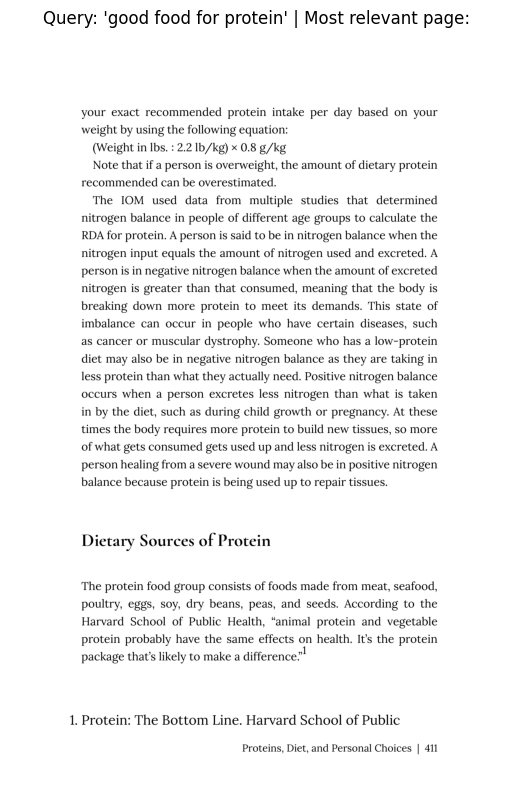

In [47]:
import fitz # pymu=pdf working library

# open PDF and load target 
pdf_path = "human-nutrition-text.pdf"
doc = fitz.open(pdf_path)
page=doc.load_page(411+41) # note: page numbers of our PDF start 41+

# Get the image of the page
img = page.get_pixmap(dpi=300)


# Save image(optional)
# img.save("Output_filename.png")
doc.close()

# Convert the pixmap to a numpy array
img_array = np.frombuffer(img.samples_mv,
                          dtype=np.uint8).reshape((img.h, img.w,img.n))

# Display the image.using matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(13,10))
plt.imshow(img_array)
plt.title(f"Query: '{query}' | Most relevant page: ")
plt.axis("off")
plt.show()

### Similarity measures: dot product and cosine similarity

Two of the most common similarity measures between vectors are dot product and cosine similarity.

In essence, closer vectors will have higher scores, further away vectors will have lower scores.

vectors have direction (which way it is going) and magnitude(how long is it?).

In [48]:
embeddings[0]

tensor([ 6.7424e-02,  9.0228e-02, -5.0955e-03, -3.1755e-02,  7.3908e-02,
         3.5198e-02, -1.9799e-02,  4.6769e-02,  5.3573e-02,  5.0123e-03,
         3.3393e-02, -1.6221e-03,  1.7608e-02,  3.6265e-02, -3.1667e-04,
        -1.0712e-02,  1.5426e-02,  2.6218e-02,  2.7765e-03,  3.6494e-02,
        -4.4411e-02,  1.8936e-02,  4.9012e-02,  1.6402e-02, -4.8578e-02,
         3.1829e-03,  2.7299e-02, -2.0476e-03, -1.2283e-02, -7.2805e-02,
         1.2045e-02,  1.0730e-02,  2.1000e-03, -8.1777e-02,  2.6783e-06,
        -1.8143e-02, -1.2080e-02,  2.4717e-02, -6.2747e-02,  7.3544e-02,
         2.2162e-02, -3.2877e-02, -1.8010e-02,  2.2295e-02,  5.6136e-02,
         1.7951e-03,  5.2593e-02, -3.3174e-03, -8.3388e-03, -1.0628e-02,
         2.3192e-03, -2.2393e-02, -1.5301e-02, -9.9306e-03,  4.6532e-02,
         3.5747e-02, -2.5476e-02,  2.6369e-02,  3.7491e-03, -3.8268e-02,
         2.5833e-02,  4.1287e-02,  2.5818e-02,  3.3297e-02, -2.5178e-02,
         4.5152e-02,  4.4903e-04, -9.9662e-02,  4.9

Cosine Similarity: Measures the similaity between two vectors of an inner product space

In [49]:
import torch

def dot_product(vector1, vector2):
    return torch.dot(vector1,vector2)

def cosine_similarity(vector1, vector2):
    dot_product = torch.dot(vector1, vector2)

    # get euclidean / L2 norm
    norm_vector1 = torch.sqrt(torch.sum(vector1**2))
    norm_vector2 = torch.sqrt(torch.sum(vector2**2))


    return dot_product / (norm_vector1 * norm_vector2)

# Example vectors/tensors
vector1 = torch.tensor([1,2,3], dtype=torch.float32)
vector2 = torch.tensor([1,2,3], dtype=torch.float32)
vector3 = torch.tensor([4,5,6], dtype=torch.float32)
vector4 = torch.tensor([-1,-2,-3], dtype=torch.float32)

# Calculate dot product
print("Dot product between vector1 and vector2:", dot_product(vector1, vector2))
print("Dot product between vector1 and vector3:", dot_product(vector1, vector3))
print("Dot product between vector1 and vector4:", dot_product(vector1, vector4))


# Cosine similarity
print("Cosine similarity between vector1 and vector2:", cosine_similarity(vector1,vector2))
print("Cosine similarity between vector1 and vector3:", cosine_similarity(vector1,vector3))
print("Cosine similarity between vector1 and vector4:", cosine_similarity(vector1,vector4))

Dot product between vector1 and vector2: tensor(14.)
Dot product between vector1 and vector3: tensor(32.)
Dot product between vector1 and vector4: tensor(-14.)
Cosine similarity between vector1 and vector2: tensor(1.0000)
Cosine similarity between vector1 and vector3: tensor(0.9746)
Cosine similarity between vector1 and vector4: tensor(-1.0000)


### Functionizing our semantic search pipelines

Let's put all of the steps from above for semantic search into a function or two so we can repeat the workflow.

In [50]:
from time import perf_counter as timer
from sentence_transformers import util, SentenceTransformer
def retrieve_relevant_resources(query:str, 
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=True):
    
    """
    embeds a query with model and returns top k scores and indice from embeddings.

    """

    # Embed a query 
    query_embedding = model.encode(query, convert_to_tensor=True)

    # Get dot product scores on embeddings
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Time Taken to get scores on ({len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

    scores, indices = torch.topk(input=dot_scores,
                                k=n_resources_to_return)

    return scores, indices

def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict]=pages_and_chunks,
                                 n_resources_to_return: int=5):
    """
    Find the relevant passages given a query and print them out along with their scores.
    """

    scores, indices = retrieve_relevant_resources(query=query,
                                                 embeddings=embeddings,
                                                 n_resources_to_return =n_resources_to_return)

    # Loop through zipped together scores and indices from torch.topk
    for score, idx in zip(scores, indices):
        print(f"Score: {score:.4f}")
        print("Text:")
        print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
        print(f"page number: {pages_and_chunks[idx]['page_number']}")
        print("\n")

In [51]:
embeddings.shape

torch.Size([1680, 768])

In [52]:
query="foods high in fiber"
retrieve_relevant_resources(query=query, embeddings=embeddings)
print_top_results_and_scores(query=query, embeddings=embeddings)

[INFO] Time Taken to get scores on (1680 embeddings: 0.00019 seconds.
[INFO] Time Taken to get scores on (1680 embeddings: 0.00022 seconds.
Score: 0.6964
Text:
• Change it up a bit and experience the taste and satisfaction of other whole
grains such as barley, quinoa, and bulgur. • Eat snacks high in fiber, such as
almonds, pistachios, raisins, and air-popped popcorn. Add an artichoke and green
peas to your dinner plate more 276 | Carbohydrates and Personal Diet Choices
page number: 276


Score: 0.6810
Text:
Dietary fiber is categorized as either water-soluble or insoluble. Some examples
of soluble fibers are inulin, pectin, and guar gum and they are found in peas,
beans, oats, barley, and rye. Cellulose and lignin are insoluble fibers and a
few dietary sources of them are whole-grain foods, flax, cauliflower, and
avocados. Cellulose is the most abundant fiber in plants, making up the cell
walls and providing structure. Soluble fibers are more easily accessible to
bacterial enzymes in 

### Getting an LLM for local generation

We want to focus on local generation.

however, this process work for an LLM api.

What is an generative LLM?

Goes from text input -> generate text output.

Which LLM should I use?

* how much hardware VRAM do you have available

### Checking our Local GPU memory availability

In [53]:
# Get GPU available memory
import torch
gpu_memory_bytes = torch.cuda.get_device_properties(0).total_memory
gpu_memory_gb = round(gpu_memory_bytes / (2**30))
print(f"Available GPU memory: {gpu_memory_gb} GB")

Available GPU memory: 4 GB


Note: 
* to use 'gemma-7b-it' or other Gemma models, you have to accept t & c on Hugging Fsce
* to download models and run locally from fugging face, you may need o sign in to hugging face and cli.

In [54]:
if gpu_memory_gb < 2.0:
    print(f"Your available GPU memory is {gpu_memory_gb}GB — insufficient to run any Gemma model locally, even with quantization.")
    use_quantization_config = False
    model_id = None

elif gpu_memory_gb < 5.1:
    # Can run Gemma 2B 4-bit but below recommended memory — may be slow or unstable
    print(f"GPU memory: {gpu_memory_gb}GB | Running Gemma 2B in 4-bit precision (below recommended 5GB — expect limited performance).")
    use_quantization_config = True
    model_id = "google/gemma-2b-it"

elif gpu_memory_gb < 8.1:
    # Comfortably runs Gemma 2B 4-bit; within recommended range
    print(f"GPU memory: {gpu_memory_gb}GB | Recommended model: Gemma 2B in 4-bit precision.")
    use_quantization_config = True
    model_id = "google/gemma-2b-it"

elif gpu_memory_gb < 19.0:
    # Enough for Gemma 2B float16 (~4.73GB) or Gemma 7B 4-bit (~5.14GB)
    # Prefer 7B 4-bit for better quality if >= 8GB
    if gpu_memory_gb >= 8.1:
        print(f"GPU memory: {gpu_memory_gb}GB | Recommended model: Gemma 7B in 4-bit precision.")
        use_quantization_config = True
        model_id = "google/gemma-7b-it"
    else:
        print(f"GPU memory: {gpu_memory_gb}GB | Recommended model: Gemma 2B in float16 precision.")
        use_quantization_config = False
        model_id = "google/gemma-2b-it"

else:
    # >= 19GB: can run Gemma 7B in float16 comfortably
    print(f"GPU memory: {gpu_memory_gb}GB | Recommended model: Gemma 7B in float16 precision.")
    use_quantization_config = False
    model_id = "google/gemma-7b-it"

if model_id:
    print(f"use_quantization_config set to: {use_quantization_config}")
    print(f"model_id set to: {model_id}")

GPU memory: 4GB | Running Gemma 2B in 4-bit precision (below recommended 5GB — expect limited performance).
use_quantization_config set to: True
model_id set to: google/gemma-2b-it


### Loading an LLM locally

We can load an LLM locally using Hugging face `transformers`.

The model I'm going to use on my NVIDIA RTX 2050 - https://huggingface.co/google/gemma-2b-it 

To get a model runnning local we're going to need a few things:
1. A quantization config (optional) - a config on what precision to load the model in (e.g. 8bit, 4bit, etc)
2. A model ID - this will tell transformers which model/tokenizer to load
3. A tokenizer - this turns text into numbers ready for the LLM (not: a tokenizer is different from an embeddding model)
4. An LLM model - this will be what we use to generate text based on an input!.

> **NOTE:**  There are many tips and tricks on loading/making LLM work faster. One of the best ones is flash_attn (Flash Attention 2) - https://github.com/dao-ailab/flash-attention.

In [55]:
torch.cuda.get_device_capability(0)[0]

8

In [56]:
import torch
import bitsandbytes
import transformers
import accelerate

print("Torch:", torch.__version__)
print("BitsAndBytes:", bitsandbytes.__version__)
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.6.0+cu124
BitsAndBytes: 0.43.3
Transformers: 4.44.0
Accelerate: 0.33.0
CUDA available: True
GPU: NVIDIA GeForce RTX 2050


In [57]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.utils import is_flash_attn_2_available
from transformers import BitsAndBytesConfig


use_quantization_config = True
# 1. Create a quantization config
# Note: requires !pip install bitsandbytes accelerate
from transformers import BitsAndBytesConfig
quantization_config = BitsAndBytesConfig(load_in_4bit=True,
                                         bnb_4bit_compute_dtype=torch.float16)

# Bonus: Flash attenton 2 = Faster attention mechanism
# Flash attention 2 requires a GPU with a compute capability score of 8.0+ (Ampere, Ada LoveLace, Hopper and above)
if (is_flash_attn_2_available()) and (torch.cuda.get_device_capability(0)[0] >= 8):
     attn_implementation = "flash_attention_2"
else:
    attn_implementation = "sdpa" # scaled dot product attention

# 2. Pick a model we'd like to use
# model_id = "google/gemma-2b-it"
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"


# 3. Instantiate tokenizer (tokenizer turns text into tokens)
tokenizer  = AutoTokenizer.from_pretrained(model_id)

# 4. Instantiate the model 
llm_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=model_id,
    torch_dtype=torch.float16,
    quantization_config=quantization_config if use_quantization_config else None,
    # 
    attn_implementation=attn_implementation
)


`low_cpu_mem_usage` was None, now set to True since model is quantized.


In [58]:
is_flash_attn_2_available()

False

In [59]:
print(f"Using attention implementation : {attn_implementation}")

Using attention implementation : sdpa


In [60]:
llm_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear4bit(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear4bit(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05

In [61]:
def get_model_num_params(model: torch.nn.Module):
    return sum([param.numel() for param in model.parameters()])

get_model_num_params(llm_model)

615606272

In [62]:
def get_model_memory_size(model: torch.nn.Module):
        # get model parmaters and buffer sizes
        mem_params = sum([param.nelement() * param.element_size() for param in model.parameters()])
        mem_buffers = sum([buf.nelement() * buf.element_size() for buf in model.buffers()])

        # Calculate model sizes 
        model_mem_bytes = mem_params + mem_buffers
        model_mem_mb= model_mem_bytes / (1024**2)
        model_mem_gb= model_mem_bytes / (1024**3)

        return {"model_mem_bytes":model_mem_bytes,
                "model_mem_mb":round(model_mem_mb,2),
                "model_mem_gb":round(model_mem_gb,2)}

get_model_memory_size(llm_model)

{'model_mem_bytes': 746773376, 'model_mem_mb': 712.18, 'model_mem_gb': 0.7}

We got the size our model.

This means to load TinyLlama-1.1B-Chat-v1.0 in float16 we need a minimum of 2-4GB of VRAM, However due to the calculations that take place in the forward pass, we actually need closer to  4GB.

### Generate text with our LLM

Let's generate text with our local LLM!

* Note: Some models have been trained/tuned to generate text with a specific template in mind.

because `TinyLlama/TinyLlama-1.1B-Chat-v1.0` has been trained in an instruction-tuned manner, we should follow the instruction template for the best results. 

In [63]:
input_text = "What are the macronutrients, and what roles do they play in the human body?"
print(f"Input text: \n{input_text}")

# Create prompt template for instruction-tuned model
dialog_template = [
    {"role":"user",
     "content":input_text}
]

# Apply the chat template
prompt = tokenizer.apply_chat_template(conversation=dialog_template,
                                       tokenize=False,
                                       add_generation_prompt=True)

print(f"\nPrompt (formatted):\n{prompt}")

Input text: 
What are the macronutrients, and what roles do they play in the human body?

Prompt (formatted):
<|user|>
What are the macronutrients, and what roles do they play in the human body?</s>
<|assistant|>



In [64]:
%%time

# Tokenize the input text(turn it into numbers) and send it to  the GPU
input_ids = tokenizer(prompt,
                      return_tensors="pt").to("cuda")

# Generate outputs from local LLM
outputs = llm_model.generate(**input_ids,
                             max_new_tokens=256)

print(f"Model Output (tokens):\n{outputs[0]}\n")

Model Output (tokens):
tensor([    1,   529, 29989,  1792, 29989, 29958,    13,  5618,   526,   278,
         5825,  1617,   329,   374,  1237, 29892,   322,   825, 16178,   437,
          896,  1708,   297,   278,  5199,  3573, 29973,     2, 29871,    13,
        29966, 29989,   465, 22137, 29989, 29958,    13,  1576,  5825,  1617,
          329,   374,  1237,   526,   278,  3023, 18853,   626,  1789,  1274,
         4841,   313, 14676,   262,  5214, 10930, 29897,   393,  1207,   701,
          278,  5214, 10930,   310, 26823, 29901,    13,    13, 29896, 29889,
         1704,   833, 29882,  2941, 29878,  1078, 29901,  1704,   833, 29882,
         2941, 29878,  1078,   526,   278,  1667,  2752,   310,  5864,   363,
          278,  5199,  3573, 29889,  2688,  3867,   278,  3573,   411,  3144,
         1682,   852, 29892,   607,   338,  1304,   363,  5864,  5802, 29889,
           13,    13, 29906, 29889, 14409,  1144, 29901, 14409,  1144,   526,
          278,  5214, 10930,   310,   260

In [65]:
### Decode the output tokens to text
output_decoded = tokenizer.decode(outputs[0])
print(f"Model output(decoded): \n{output_decoded}")

Model output(decoded): 
<s> <|user|>
What are the macronutrients, and what roles do they play in the human body?</s> 
<|assistant|>
The macronutrients are the four essential amino acids (protein building blocks) that make up the building blocks of protein:

1. Carbohydrates: Carbohydrates are the main source of energy for the human body. They provide the body with glucose, which is used for energy production.

2. Proteins: Proteins are the building blocks of tissues and organs in the human body. They are essential for maintaining the structure and function of the body.

3. Fatty Acids: Fatty acids are essential for the proper functioning of the body's internal organs. They are also important for the production of hormones and the transport of nutrients.

4. Carbohydrates: Carbohydrates are essential for energy production and are used to provide energy to the body. They are also important for the production of cellular energy.

The macronutrients play a crucial role in the human body's 

In [66]:
# Nutrition-style questions generated with GPT4
gpt4_questions = [
    "What are the macronutrients, and what roles do they play in the human body?",
    "How do vitamins and minerals differ in their roles and importance for health?",
    "Describe the process of digestion and absorption of nutrients in the human body.",
    "What role does fibre play in digestion? Name five fibre containing foods.",
    "Explain the concept of energy balance and its importance in weight management."
]

# Manually created question list
manual_questions = [
    "How often should infants be breastfed?",
    "What are symptoms of pellagra?",
    "How does saliva help with digestion?",
    "What is the RDI for protein per day?",
    "water soluble vitamins"
]

query_list = gpt4_questions + manual_questions
query_list

['What are the macronutrients, and what roles do they play in the human body?',
 'How do vitamins and minerals differ in their roles and importance for health?',
 'Describe the process of digestion and absorption of nutrients in the human body.',
 'What role does fibre play in digestion? Name five fibre containing foods.',
 'Explain the concept of energy balance and its importance in weight management.',
 'How often should infants be breastfed?',
 'What are symptoms of pellagra?',
 'How does saliva help with digestion?',
 'What is the RDI for protein per day?',
 'water soluble vitamins']

In [67]:
import random
query = random.choice(query_list)

print(f"Query: {query}")

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

Query: What role does fibre play in digestion? Name five fibre containing foods.
[INFO] Time Taken to get scores on (1680 embeddings: 0.00012 seconds.


(tensor([0.5964, 0.5766, 0.5745, 0.5707, 0.5600], device='cuda:0'),
 tensor([1548,  360,  373,  380,  379], device='cuda:0'))

### Augmenting our prompt with context items

We've done retrieval.

We've done generation.

Time to augment!

The Concept of augmenting a prompt with context items is also referred as prompt engineering.

> **Note:** The process of augmenting or changing a prompt to an LLM is known as prompt engineering. And the best way to do it is an active area of research. For a comprehensive guide on different prompt engineering techniques, I'd recommend the Prompt Engineering Guide ([promptingguide.ai](https://www.promptingguide.ai/)), [Brex's Prompt Engineering Guide](https://github.com/brexhq/prompt-engineering) and the paper [Prompt Design and Engineering: Introduction and Advanced Models](https://arxiv.org/abs/2401.14423).

We're going to use a couple of prompting techniques:
1. Give clear instructions.
2. Give a few examples of input/output (e.g. given this input, I'd like this output).
3. Give room to think (e.g. create a scratchpad/"show your working space"/"let's think step by step..."".

In [68]:
pages_and_chunks[611]

{'page_number': 411,
 'sentence_chunk': 'Dietary Sources of Protein The protein food group consists of foods made from meat, seafood, poultry, eggs, soy, dry beans, peas, and seeds. According to the Harvard School of Public Health, “animal protein and vegetable protein probably have the same effects on health. It’s the protein package that’s likely to make a difference.”1 1. Protein: The Bottom Line. Harvard School of Public Proteins, Diet, and Personal Choices | 411',
 'chunk_char_count': 430,
 'chunk_word_count': 69,
 'chunk_token_count': 107.5,
 'embedding': array([ 3.57393846e-02,  4.69983816e-02,  2.42606248e-03, -1.34758456e-02,
         4.41606194e-02,  1.58369855e-03, -5.75249307e-02,  7.43902475e-02,
        -2.55552661e-02, -5.65149225e-02, -2.50401292e-02,  1.29941700e-03,
         5.23344949e-02,  2.63163280e-02,  1.98242422e-02, -4.84029716e-03,
         1.22621674e-02,  6.03821464e-02,  2.70720534e-02,  2.33721323e-02,
        -3.14020962e-02, -5.45083685e-03,  1.16759017

In [74]:
context_items

[{'page_number': 565,
  'sentence_chunk': 'Niacin deficiency is commonly known as pellagra and the symptoms include fatigue, decreased appetite, and indigestion. These symptoms are then commonly followed by the four D’s: diarrhea, dermatitis, dementia, and sometimes death. Figure 9.12 Conversion of Tryptophan to Niacin Water-Soluble Vitamins | 565',
  'chunk_char_count': 306,
  'chunk_word_count': 43,
  'chunk_token_count': 76.5,
  'embedding': array([ 2.01436710e-02,  8.51659570e-03,  3.45250219e-02,  3.82414274e-02,
          6.64332435e-02,  3.54783982e-02, -4.80622537e-02,  4.61080391e-03,
          3.34752753e-04,  1.60651691e-02,  3.92620340e-02,  6.21891692e-02,
         -1.17300423e-02, -5.21841906e-02,  2.41388325e-02,  5.63626960e-02,
         -1.34784440e-02,  3.53666930e-03,  2.67130136e-02,  2.86840722e-02,
         -1.54797863e-02,  1.54494541e-02,  1.49387131e-02, -1.47909950e-02,
         -3.16866525e-02, -4.39014100e-02,  1.52432201e-02,  1.12246501e-03,
          5.22

In [96]:
def prompt_formatter(query:str,
                     context_items: list[dict]) -> str:
    context = "- " + "\n- ".join([item["sentence_chunk"] for item in context_items])
    base_prompt = """Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.
\nExample 1:
Query: What are the fat-soluble vitamins?
Answer: The fat-soluble vitamins include Vitamin A, Vitamin D, Vitamin E, and Vitamin K. These vitamins are absorbed along with fats in the diet and can be stored in the body's fatty tissue and liver for later use. Vitamin A is important for vision, immune function, and skin health. Vitamin D plays a critical role in calcium absorption and bone health. Vitamin E acts as an antioxidant, protecting cells from damage. Vitamin K is essential for blood clotting and bone metabolism.
\nExample 2:
Query: What are the causes of type 2 diabetes?
Answer: Type 2 diabetes is often associated with overnutrition, particularly the overconsumption of calories leading to obesity. Factors include a diet high in refined sugars and saturated fats, which can lead to insulin resistance, a condition where the body's cells do not respond effectively to insulin. Over time, the pancreas cannot produce enough insulin to manage blood sugar levels, resulting in type 2 diabetes. Additionally, excessive caloric intake without sufficient physical activity exacerbates the risk by promoting weight gain and fat accumulation, particularly around the abdomen, further contributing to insulin resistance.
\nExample 3:
Query: What is the importance of hydration for physical performance?
Answer: Hydration is crucial for physical performance because water plays key roles in maintaining blood volume, regulating body temperature, and ensuring the transport of nutrients and oxygen to cells. Adequate hydration is essential for optimal muscle function, endurance, and recovery. Dehydration can lead to decreased performance, fatigue, and increased risk of heat-related illnesses, such as heat stroke. Drinking sufficient water before, during, and after exercise helps ensure peak physical performance and recovery.
\nNow use the following context items to answer the user query:
{context}
\nRelevant passages: <extract relevant passages from the context here>
User query: {query}
Answer:"""
    base_prompt = base_prompt.format(context=context,
                                query=query)
    # create prompt template for instructions chained model
    # dialogue_template = [
    #     {"role":"user",
    #      "content":base_prompt}
    # ]
    # # Apply the chat template
    # prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
    #                                        tokenize=False,
                                           # add_generation_prompt=True)
    prompt=base_prompt
    return prompt
    

query = random.choice(query_list)
print(f"Query: {query}")

# Get relevant resources
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)

# Create a list of context items
context_items = [pages_and_chunks[i] for i in indices]

# format our prompt 
prompt = prompt_formatter(query=query,
                         context_items=context_items)

print(prompt)

Query: Describe the process of digestion and absorption of nutrients in the human body.
[INFO] Time Taken to get scores on (1680 embeddings: 0.00034 seconds.
Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.

Example 1:
Query: What are the fat-soluble vitamins?
Answer: The fat-soluble vitamins include Vitamin A, Vitamin D, Vitamin E, and Vitamin K. These vitamins are absorbed along with fats in the diet and can be stored in the body's fatty tissue and liver for later use. Vitamin A is important for vision, immune function, and skin health. Vitamin D plays a critical role in calcium absorption and bone health. Vitamin E acts as an antioxidant, protecting cells from damage. Vitamin K is essential for 

In [97]:
%%time

input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

# Generate an output of tokens
outputs = llm_model.generate(**input_ids,
                             #temprature=0.7,  # from 0 to 1 and the lower the value, the more deterministic the text, the higher the value, the more creative content will be
                             do_sample=True,  # whether or not to use sampling
                             max_new_tokens=256)
# turn outputs tokens into text
output_text = tokenizer.decode(outputs[0])
print(f"Query: {query}")
print(f"RAG answer:\n{output_text.replace(prompt,'')}")

Query: Describe the process of digestion and absorption of nutrients in the human body.
RAG answer:
<s>  The process of digestion and absorption of nutrients in the human body is one of the eleven organ systems in the human body. Nutrients are processed by cells throughout the body. The digestive system is one of the eleven organ systems of the human body, and it is composed of several hollow tube-shaped organs including the mouth, pharynx, esophagus, stomach, small intestine, large intestine, colon, rectum, and anus. The digestive system is one of the eleven organ systems of the human body and is composed of several hollow tube- shaped organs including the mouth, pharynx, esophagus, stomach, small intestine, large intestine and anus. Nutrients move through the digestive system from the stomach through the first part of the small intestine to the colon at the end of the digestive system. This digestion is carried out by bacteria called bacteria fermentation, and carbon dioxide and mucu

### Functionize our LLM answering feature 

Wouldn't it be cool if our RAG pipeline worked from a single function?

e.g. you input a query and you get a generated answer + optionally aslo get the source documents(the context) where that answer was generated from.

In [105]:
def ask(query:str,
       temprature: int=0.2,
        max_new_token:int=256,
        format_answer_text = True,
        return_answer_only=True):

    """
    Takes a query, 
    Find relevant resources/context,
    and generates an answer to the query based on the relevant resurces.
    """
    # RETRIEVAL 
    # get just the scores and indices of top related results
    scores, indices = retrieve_relevant_resources(query=query,
                                                    embeddings=embeddings)

    # create a list of context items
    context_items = [pages_and_chunks[i] for i in indices]

    # Add score to context items
    for i, item in enumerate(context_items):
        item["score"] = scores[i].cpu()

    # AUGMENTATION
    # Create the prompt and format it with context items
    prompt = prompt_formatter(query=query,
                              context_items=context_items)

    # GENERATION
    # Tokenize the prompt
    input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

    # Generate an output of tokens
    outputs = llm_model.generate(**input_ids,

                                 do_sample=True,
                                 max_new_tokens=256)

    # Decode the tokens into text
    output_text = tokenizer.decode(outputs[0])

    # Format the answer 
    if format_answer_text:
        # Replace prompt and special tokens
        output_text = output_text.replace(prompt, "").replace("<bos>","").replace("<eos>", "")

    # Only return the answer without context items
    if return_answer_only:
        return output_text

    return output_text, context_items

In [106]:
query=random.choice(query_list)
print(f"Query : {query}")
ask(query=query)

Query : Describe the process of digestion and absorption of nutrients in the human body.
[INFO] Time Taken to get scores on (1680 embeddings: 0.00037 seconds.


'<s>  Digestion and Absorption is the process of breaking down food into smaller components. Food is absorbed into the bloodstream and taken into the body’s cells where it is further metabolized to produce energy, essential nutrients, or other compounds that the body needs. Digestion is the process of breaking down food into nutrients that can be absorbed by the body via the small intestine, colon, rectum, and anus. Food that cannot be broken down by the digestive system is discarded within the body or excreted in the form of feces. For example, nutrients such as iron, Vitamin C, and Vitamin B6 are essential for the body, and they are absorbed through three digestive passages:\n- The small intestine\n- The colon\n- The large intestine (colon)\n\nThe small intestine or small intestine (colon) is the first line of defense against bacteria, viruses or parasites. In the small intestine (colon), nutrients in the food pass from the small intestine into the bloodstream for transportation to b

Local RAG workflow complete!

We've now officially got a way to Retrieve, Augment and Generate answers based on a source.

For now we can verify our answers manually by reading them and reading through the textbook.

But if you want to put this into a production system, it'd be a good idea to have some kind of evaluation on how well our pipeline works.

For example, you could use another LLM to rate the answers returned by our LLM and then use those ratings as a proxy evaluation.

However, I'll leave this and a few more interesting ideas as extensions.

## Extensions

* May want to improve text extraction with something like Marker - https://github.com/VikParuchuri/marker
* Guide to more advanced PDF extraction - https://towardsdatascience.com/extracting-text-from-pdf-files-with-python-a-comprehensive-guide-9fc4003d517 
* See the following prompt engineering resources for more prompting techniques - promptinguide.ai, Brex's Prompt Engineering Guide 
* What happens when a query comes through that there isn't any context in the textbook on?
* Try another embedding model (e.g. Mixed Bread AI large, `mixedbread-ai/mxbai-embed-large-v1`, see: https://huggingface.co/mixedbread-ai/mxbai-embed-large-v1)
* Try another LLM... (e.g. Mistral-Instruct)
* Try different prompts (e.g. see prompting techniques online)
* Our example only focuses on text from a PDF, however, we could extend it to include figures and images 
* Evaluate the answers -> could use another LLM to rate our answers (e.g. use GPT-4 to make)
* Vector database/index for larger setup (e.g. 100,000+ chunks)
* Libraries/frameworks such as LangChain / LlamaIndex can help do many of the steps for you - so it's worth looking into those next, wanted to recreate a workflow with lower-level tools to show the principles
* Optimizations for speed
    * See Hugging Face docs for recommended speed ups on GPU - https://huggingface.co/docs/transformers/perf_infer_gpu_one 
    * Optimum NVIDIA - https://huggingface.co/blog/optimum-nvidia, GitHub: https://github.com/huggingface/optimum-nvidia 
    * See NVIDIA TensorRT-LLM - https://github.com/NVIDIA/TensorRT-LLM 
    * See GPT-Fast for PyTorch-based optimizations - https://github.com/pytorch-labs/gpt-fast 
    * Flash attention 2 (requires Ampere GPUs or newer) - https://github.com/Dao-AILab/flash-attention
* Stream text output so it looks prettier (e.g. each token appears as it gets output from the model)
* Turn the workflow into an app, see Gradio type chatbots for this - https://www.gradio.app/guides/creating-a-chatbot-fast, see local example: https://www.gradio.app/guides/creating-a-chatbot-fast#example-using-a-local-open-source-llm-with-hugging-face 